In [1]:
# Cell 1: Mount Drive and create SlowFast project folders

from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = "/content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast"

folders = [
    BASE_DIR,
    f"{BASE_DIR}/checkpoints",
    f"{BASE_DIR}/best_model",
    f"{BASE_DIR}/history",
    f"{BASE_DIR}/graphs",
    f"{BASE_DIR}/logs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders are ready.")
for folder in folders:
    print(folder)

Mounted at /content/drive
Project folders are ready.
/content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast
/content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/checkpoints
/content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/best_model
/content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/history
/content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/graphs
/content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/logs


In [2]:
# Cell 2: Install required packages for SlowFast

!pip install -q pytorchvideo av fvcore iopath

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 67.9 MB/s eta 0:00:00


In [4]:
# Cell 3: Download dataset from Kaggle, extract it, and verify final folder structure

import os
import zipfile
import shutil

DATASET_DIR = "/content/TikHarm_frames_16"
ZIP_PATH = "/content/tikharm_dataset.zip"

# Remove old partial folder if it exists
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

# Kaggle download
!kaggle datasets download -d aryansraut/preprocessed-ucf-crime-dataset-visual -p /content --force

# Find downloaded zip
zip_files = [f for f in os.listdir("/content") if f.endswith(".zip")]
print("ZIP files in /content:", zip_files)

# Use the expected zip if present, otherwise first zip
if os.path.exists(ZIP_PATH):
    selected_zip = ZIP_PATH
else:
    selected_zip = os.path.join("/content", zip_files[0]) if zip_files else None

print("Selected ZIP:", selected_zip)

# Extract
if selected_zip and os.path.exists(selected_zip):
    with zipfile.ZipFile(selected_zip, 'r') as zip_ref:
        zip_ref.extractall("/content")
    print("Extraction completed.")
else:
    print("No ZIP file found. Check Kaggle setup.")

# Final check
print("\nFinal dataset check:")
print("Dataset exists:", os.path.exists(DATASET_DIR))
for split in ["train", "val", "test"]:
    split_path = os.path.join(DATASET_DIR, split)
    print(f"{split.upper()} exists:", os.path.exists(split_path))
    if os.path.exists(split_path):
        print(f"{split} classes:", sorted(os.listdir(split_path)))

Dataset URL: https://www.kaggle.com/datasets/aryansraut/preprocessed-ucf-crime-dataset-visual
License(s): apache-2.0
100% 1.04G/1.04G [01:06<00:00, 16.8MB/s]

ZIP files in /content: ['preprocessed-ucf-crime-dataset-visual.zip']
Selected ZIP: /content/preprocessed-ucf-crime-dataset-visual.zip
Extraction completed.

Final dataset check:
Dataset exists: True
TRAIN exists: True
train classes: ['Adult Content', 'Harmful Content', 'Safe', 'Suicide']
VAL exists: True
val classes: ['Adult Content', 'Harmful Content', 'Safe', 'Suicide']
TEST exists: True
test classes: ['Adult Content', 'Harmful Content', 'Safe', 'Suicide']


In [5]:
# Cell 4: Set paths, seed, and class mapping

import os
import random
import numpy as np
import torch

# Paths
DATASET_DIR = "/content/TikHarm_frames_16"
BASE_DIR = "/content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast"
CHECKPOINT_DIR = f"{BASE_DIR}/checkpoints"
BEST_MODEL_DIR = f"{BASE_DIR}/best_model"
HISTORY_DIR = f"{BASE_DIR}/history"
GRAPHS_DIR = f"{BASE_DIR}/graphs"
LOGS_DIR = f"{BASE_DIR}/logs"

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Classes
class_names = ['Adult Content', 'Harmful Content', 'Safe', 'Suicide']
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}
idx_to_class = {idx: cls_name for cls_name, idx in class_to_idx.items()}

print("Device:", device)
print("Class to index mapping:", class_to_idx)
print("Base save path:", BASE_DIR)

Device: cuda
Class to index mapping: {'Adult Content': 0, 'Harmful Content': 1, 'Safe': 2, 'Suicide': 3}
Base save path: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast


In [6]:
# Cell 5: Build dataset index for train, val, and test

def build_split_index(split_dir, class_to_idx):
    samples = []
    for class_name in class_names:
        class_dir = os.path.join(split_dir, class_name)
        if not os.path.exists(class_dir):
            continue

        for sample_folder in sorted(os.listdir(class_dir)):
            sample_path = os.path.join(class_dir, sample_folder)
            if os.path.isdir(sample_path):
                samples.append((sample_path, class_to_idx[class_name]))

    return samples

train_samples = build_split_index(os.path.join(DATASET_DIR, "train"), class_to_idx)
val_samples   = build_split_index(os.path.join(DATASET_DIR, "val"), class_to_idx)
test_samples  = build_split_index(os.path.join(DATASET_DIR, "test"), class_to_idx)

print("Train samples:", len(train_samples))
print("Val samples:", len(val_samples))
print("Test samples:", len(test_samples))

print("\nFirst train sample:")
print(train_samples[0] if len(train_samples) > 0 else "No train sample found")

Train samples: 2762
Val samples: 396
Test samples: 790

First train sample:
('/content/TikHarm_frames_16/train/Adult Content/...the...bad...bitch_7008189277318302981', 0)


In [14]:
# Cell 6: Create PyTorch Dataset for SlowFast (UPDATED for 32-frame input)

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import torch
import torch.nn.functional as F

# Image transform
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.45, 0.45, 0.45],
        std=[0.225, 0.225, 0.225]
    )
])

class TikHarmSlowFastDataset(Dataset):
    def __init__(self, samples, transform=None, alpha=4, target_frames=32):
        self.samples = samples
        self.transform = transform
        self.alpha = alpha
        self.target_frames = target_frames  # SlowFast pretrained model expects longer clip

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample_path, label = self.samples[idx]

        frame_files = sorted([
            f for f in os.listdir(sample_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        frames = []
        for frame_file in frame_files:
            img_path = os.path.join(sample_path, frame_file)
            img = Image.open(img_path).convert("RGB")
            if self.transform:
                img = self.transform(img)
            frames.append(img)

        # Stack -> (T, C, H, W)
        frames = torch.stack(frames)

        # If clip has 16 frames, expand to 32 by temporal interpolation
        # (T, C, H, W) -> (1, C, T, H, W)
        frames = frames.permute(1, 0, 2, 3).unsqueeze(0)
        frames = F.interpolate(
            frames,
            size=(self.target_frames, 224, 224),
            mode="trilinear",
            align_corners=False
        )
        frames = frames.squeeze(0)  # (C, T, H, W)

        fast_pathway = frames  # 32 frames

        # Slow pathway: 32 / 4 = 8 frames
        slow_indices = torch.linspace(
            0, fast_pathway.shape[1] - 1,
            fast_pathway.shape[1] // self.alpha
        ).long()
        slow_pathway = fast_pathway[:, slow_indices, :, :]

        return [slow_pathway, fast_pathway], label

train_dataset = TikHarmSlowFastDataset(train_samples, transform=image_transform, alpha=4, target_frames=32)
val_dataset   = TikHarmSlowFastDataset(val_samples, transform=image_transform, alpha=4, target_frames=32)
test_dataset  = TikHarmSlowFastDataset(test_samples, transform=image_transform, alpha=4, target_frames=32)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 2762
Val dataset size: 396
Test dataset size: 790


In [15]:
# Cell 7: Check one sample shape for SlowFast input

sample_inputs, sample_label = train_dataset[0]
slow_pathway, fast_pathway = sample_inputs

print("Slow pathway shape:", slow_pathway.shape)
print("Fast pathway shape:", fast_pathway.shape)
print("Label:", sample_label)
print("Class name:", idx_to_class[sample_label])

Slow pathway shape: torch.Size([3, 8, 224, 224])
Fast pathway shape: torch.Size([3, 32, 224, 224])
Label: 0
Class name: Adult Content


In [21]:
# Cell 8: Create DataLoaders for train, val, and test (UPDATED for lighter loading)

from torch.utils.data import DataLoader

BATCH_SIZE = 2
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1381
Val batches: 198
Test batches: 395


In [22]:
# Cell 9: Load pretrained SlowFast model and replace final layer for 4 classes

import torch
import torch.nn as nn

model = torch.hub.load('facebookresearch/pytorchvideo', 'slowfast_r50', pretrained=True)

# Replace final classification layer
in_features = model.blocks[-1].proj.in_features
model.blocks[-1].proj = nn.Linear(in_features, len(class_names))

model = model.to(device)

print("SlowFast model loaded successfully.")
print("Final output classes:", len(class_names))
print("Device:", device)

Using cache found in /root/.cache/torch/hub/facebookresearch_pytorchvideo_main


SlowFast model loaded successfully.
Final output classes: 4
Device: cuda


In [23]:
# Cell 10: Define loss, optimizer, scheduler, and save paths

import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

BEST_MODEL_PATH = f"{BEST_MODEL_DIR}/slowfast_best.pth"
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/slowfast_checkpoint.pth"
HISTORY_PATH = f"{HISTORY_DIR}/slowfast_history.json"
GRAPH_PATH = f"{GRAPHS_DIR}/slowfast_graphs.png"

print("Criterion:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Initial LR:", optimizer.param_groups[0]["lr"])
print("Best model path:", BEST_MODEL_PATH)
print("Checkpoint path:", CHECKPOINT_PATH)

Criterion: CrossEntropyLoss()
Optimizer: Adam
Initial LR: 0.0001
Best model path: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/best_model/slowfast_best.pth
Checkpoint path: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/checkpoints/slowfast_checkpoint.pth


In [24]:
# Cell 11: Define train/validate functions and checkpoint utilities

import json
from tqdm import tqdm

def save_json_history(history, path):
    with open(path, "w") as f:
        json.dump(history, f)

def save_checkpoint(epoch, model, optimizer, scheduler, best_val_acc, history, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_acc": best_val_acc,
        "history": history
    }, path)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(loader, desc="Training", leave=False):
        slow_path, fast_path = inputs
        slow_path = slow_path.to(device, non_blocking=True)
        fast_path = fast_path.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model([slow_path, fast_path])
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="Validation"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(loader, desc=desc, leave=False):
        slow_path, fast_path = inputs
        slow_path = slow_path.to(device, non_blocking=True)
        fast_path = fast_path.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model([slow_path, fast_path])
        loss = criterion(outputs, labels)

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

start_epoch = 0
best_val_acc = 0.0

print("Training utilities are ready.")
print("History path:", HISTORY_PATH)
print("Checkpoint path:", CHECKPOINT_PATH)

Training utilities are ready.
History path: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/history/slowfast_history.json
Checkpoint path: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/checkpoints/slowfast_checkpoint.pth


In [25]:
# Cell 12: Train SlowFast with validation, checkpoint saving, and best model saving (UPDATED)

EPOCHS = 8

for epoch in range(start_epoch, EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, desc="Validation")

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Accuracy: {val_acc:.4f}")
    print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"Best model saved to: {BEST_MODEL_PATH}")

    save_checkpoint(
        epoch=epoch + 1,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        best_val_acc=best_val_acc,
        history=history,
        path=CHECKPOINT_PATH
    )

    save_json_history(history, HISTORY_PATH)

    print(f"Checkpoint saved to: {CHECKPOINT_PATH}")
    print(f"History saved to: {HISTORY_PATH}")

print("\nTraining completed.")
print("Best validation accuracy:", round(best_val_acc, 4))


Epoch 1/8


Train Loss: 0.8284 | Train Accuracy: 0.6868
Val   Loss: 1.9112 | Val   Accuracy: 0.7045
Current LR: 0.000100
Best model saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/best_model/slowfast_best.pth
Checkpoint saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/checkpoints/slowfast_checkpoint.pth
History saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/history/slowfast_history.json

Epoch 2/8


Train Loss: 0.5697 | Train Accuracy: 0.7962
Val   Loss: 1.1512 | Val   Accuracy: 0.7374
Current LR: 0.000100
Best model saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/best_model/slowfast_best.pth
Checkpoint saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/checkpoints/slowfast_checkpoint.pth
History saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/history/slowfast_history.json

Epoch 3/8


Train Loss: 0.3836 | Train Accuracy: 0.8682
Val   Loss: 0.8810 | Val   Accuracy: 0.7298
Current LR: 0.000100
Checkpoint saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/checkpoints/slowfast_checkpoint.pth
History saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/history/slowfast_history.json

Epoch 4/8


Train Loss: 0.2807 | Train Accuracy: 0.9095
Val   Loss: 1.0803 | Val   Accuracy: 0.7576
Current LR: 0.000100
Best model saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/best_model/slowfast_best.pth
Checkpoint saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/checkpoints/slowfast_checkpoint.pth
History saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/history/slowfast_history.json

Epoch 5/8


Train Loss: 0.2231 | Train Accuracy: 0.9283
Val   Loss: 0.9783 | Val   Accuracy: 0.7551
Current LR: 0.000100
Checkpoint saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/checkpoints/slowfast_checkpoint.pth
History saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/history/slowfast_history.json

Epoch 6/8


Train Loss: 0.1770 | Train Accuracy: 0.9403
Val   Loss: 1.6629 | Val   Accuracy: 0.7323
Current LR: 0.000050
Checkpoint saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/checkpoints/slowfast_checkpoint.pth
History saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/history/slowfast_history.json

Epoch 7/8


Train Loss: 0.0650 | Train Accuracy: 0.9848
Val   Loss: 0.9303 | Val   Accuracy: 0.7525
Current LR: 0.000050
Checkpoint saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/checkpoints/slowfast_checkpoint.pth
History saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/history/slowfast_history.json

Epoch 8/8


Train Loss: 0.0282 | Train Accuracy: 0.9928
Val   Loss: 0.8447 | Val   Accuracy: 0.7904
Current LR: 0.000050
Best model saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/best_model/slowfast_best.pth
Checkpoint saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/checkpoints/slowfast_checkpoint.pth
History saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/history/slowfast_history.json

Training completed.
Best validation accuracy: 0.7904


In [26]:
# Cell 13: Load best model and evaluate on test set

model.load_state_dict(torch.load(BEST_MODEL_PATH))
model = model.to(device)

test_loss, test_acc = evaluate(model, test_loader, criterion, device, desc="Testing")

print("Best model loaded from:", BEST_MODEL_PATH)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Best model loaded from: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/best_model/slowfast_best.pth
Test Loss: 1.0418
Test Accuracy: 0.7696


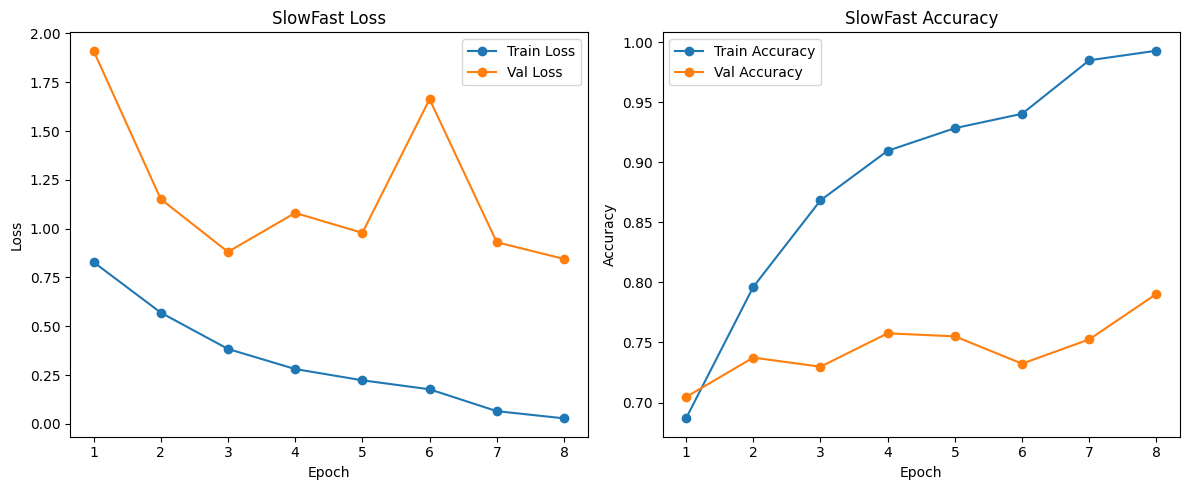

Graphs saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/graphs/slowfast_graphs.png


In [27]:
# Cell 14: Plot and save training graphs

import json
import matplotlib.pyplot as plt

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# Loss graph
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], marker='o', label="Train Loss")
plt.plot(epochs_range, history["val_loss"], marker='o', label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SlowFast Loss")
plt.legend()

# Accuracy graph
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], marker='o', label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], marker='o', label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SlowFast Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(GRAPH_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Graphs saved to:", GRAPH_PATH)

In [28]:
# Cell 15: Save final experiment summary to Drive

SUMMARY_PATH = f"{LOGS_DIR}/slowfast_summary.txt"

summary_text = f"""
Model: SlowFast (Model 2)
Assignment: Generative Modeling Assignment 2 - Option C
Scenario: Suspicious Activity Detection

Dataset:
- Source: aryansraut/preprocessed-ucf-crime-dataset-visual
- Extracted Path: /content/TikHarm_frames_16
- Classes: Adult Content, Harmful Content, Safe, Suicide

Training Setup:
- Epochs: 8
- Batch Size: 2
- Optimizer: Adam
- Initial Learning Rate: 1e-4
- Loss Function: CrossEntropyLoss

Results:
- Best Validation Accuracy: 0.7904
- Test Accuracy: 0.7696
- Test Loss: 1.0418

Saved Outputs:
- Best Model: {BEST_MODEL_PATH}
- Checkpoint: {CHECKPOINT_PATH}
- History: {HISTORY_PATH}
- Graphs: {GRAPH_PATH}
"""

with open(SUMMARY_PATH, "w") as f:
    f.write(summary_text.strip())

print("Summary saved to:", SUMMARY_PATH)
print("\n--- Summary Preview ---\n")
print(summary_text)

Summary saved to: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/logs/slowfast_summary.txt

--- Summary Preview ---


Model: SlowFast (Model 2)
Assignment: Generative Modeling Assignment 2 - Option C
Scenario: Suspicious Activity Detection

Dataset:
- Source: aryansraut/preprocessed-ucf-crime-dataset-visual
- Extracted Path: /content/TikHarm_frames_16
- Classes: Adult Content, Harmful Content, Safe, Suicide

Training Setup:
- Epochs: 8
- Batch Size: 2
- Optimizer: Adam
- Initial Learning Rate: 1e-4
- Loss Function: CrossEntropyLoss

Results:
- Best Validation Accuracy: 0.7904
- Test Accuracy: 0.7696
- Test Loss: 1.0418

Saved Outputs:
- Best Model: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/best_model/slowfast_best.pth
- Checkpoint: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/checkpoints/slowfast_checkpoint.pth
- History: /content/drive/MyDrive/GM_Assignment2_TikHarm/SlowFast/history/slowfast_history.json
- Graphs: /content/drive/MyDrive/GM_Assignment2_Ti